In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load Titanic dataset
titanic = fetch_openml(name="titanic", version=1, as_frame=True)

df = titanic.frame

print(df.head())

   pclass survived                                             name     sex  \
0       1        1                    Allen, Miss. Elisabeth Walton  female   
1       1        1                   Allison, Master. Hudson Trevor    male   
2       1        0                     Allison, Miss. Helen Loraine  female   
3       1        0             Allison, Mr. Hudson Joshua Creighton    male   
4       1        0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis,

In [3]:
print("Shape:", df.shape)

print("\nInformation")
df.info()

print("\nSummary Statistics")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

Shape: (1309, 14)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB

Summary Statistics
            pclass          age        sibsp        parch         fare  \
count  1309.000000  1046.000000  13

In [4]:
# Fill missing numeric values
numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

pclass       0
survived     0
name         0
sex          0
age          0
sibsp        0
parch        0
ticket       0
fare         0
cabin        0
embarked     0
boat         0
body         0
home.dest    0
dtype: int64


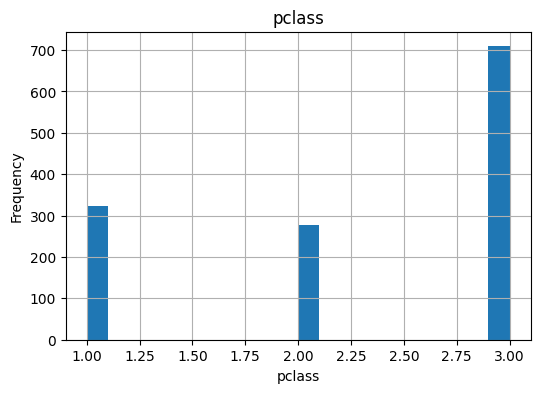

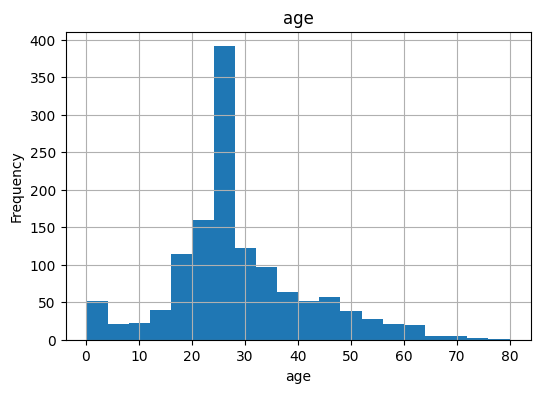

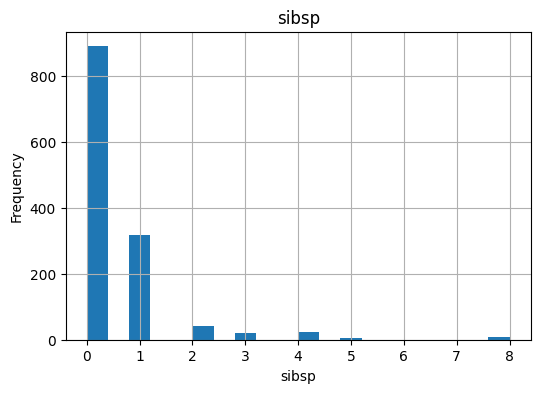

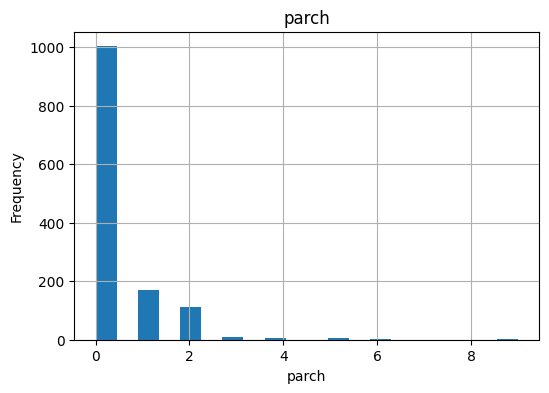

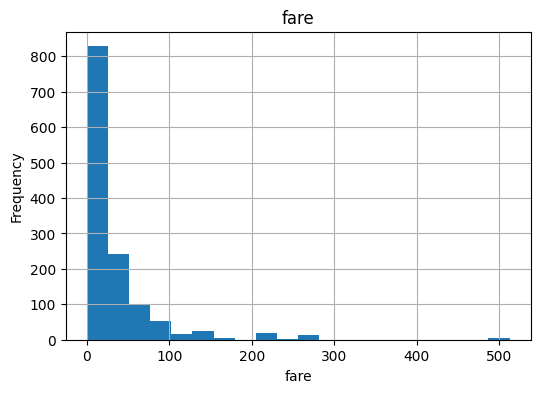

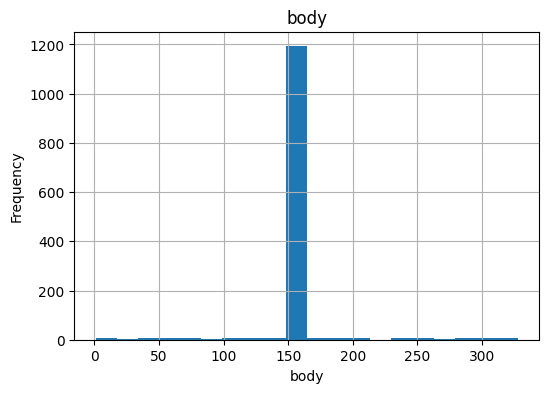

In [5]:
numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=20)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

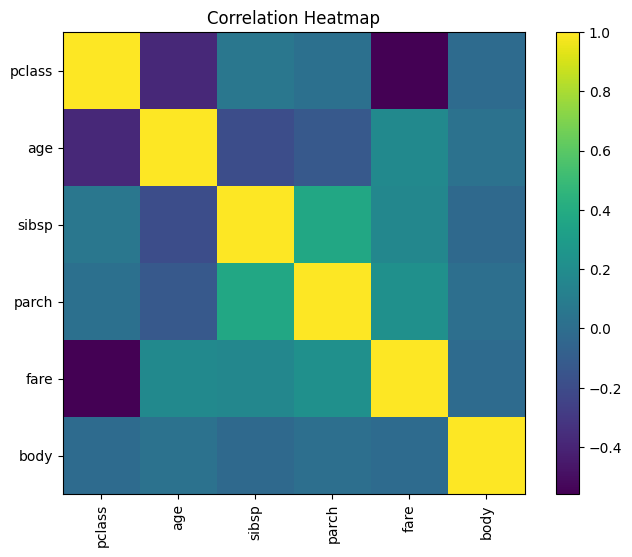

In [6]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

In [7]:
print("CrewAI : AI Agent Orchestration")

print("LangGraph : Workflow Management")

print("MLflow : Experiment Tracking")

print("Ragas : RAG Evaluation")

print("MLOps : Deployment and Monitoring")

CrewAI : AI Agent Orchestration
LangGraph : Workflow Management
MLflow : Experiment Tracking
Ragas : RAG Evaluation
MLOps : Deployment and Monitoring


In [ ]:
Five Observations
The dataset contains both numerical and categorical features.
Some columns have missing values that need preprocessing.
Passenger age has missing entries and a wide distribution.
Fare values are highly skewed with a few large outliers.
Several categorical columns have many unique values and require encoding before modeling.

In [ ]:
EDA Narrative

The exploratory data analysis of the Titanic dataset provides a clear understanding of the dataset's structure and quality. The dataset contains both numerical and categorical features, including passenger age, fare, class, sex, and survival status. Initial exploration using df.info(), df.describe(), and df.isnull().sum() revealed that several columns contain missing values, particularly the Age and Cabin columns. These missing values must be handled before building machine learning models. Numerical distributions indicate that the Fare feature is highly right-skewed, suggesting the presence of outliers, while Age appears reasonably distributed after filling missing values. The correlation analysis shows moderate relationships between some numerical variables, although no extremely strong correlations exist that would cause multicollinearity concerns. Category count plots reveal that certain passenger classes and genders are much more common than others, indicating possible class imbalance in some features. Overall, the dataset is suitable for predictive modeling after proper preprocessing, including handling missing values, encoding categorical variables, scaling numerical features where appropriate, and addressing outliers if necessary. These preprocessing steps will improve model performance and ensure that the resulting machine learning models are more accurate and reliable.